<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Regression/OLS%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SuccessRate i = proportion of climbers who summited in expedition / year / route 𝑖

General Regression Equation:


SuccessRatei​=β0​+β1​Yeari​+β2​Seasoni​+β3​Citizenshipi​+β4​Routei​+β5​SupportRatioi​+β6​Crowdingi​+β7​Exped

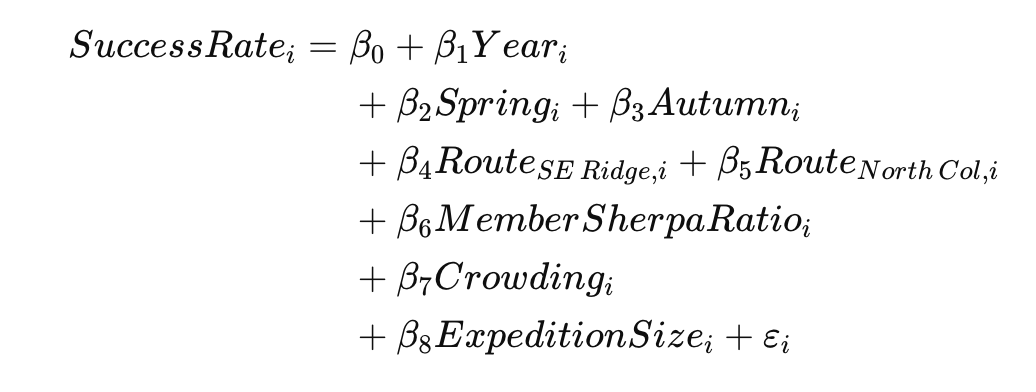

In [3]:
from google.colab import drive
drive.mount('/content/drive')

%matplotlib inline

import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
import pylab
import pandas as pd
import numpy as np

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf

pylab.rcParams['figure.figsize'] = (10., 8.)
sns.set(font_scale=1.2)
sns.set_style("white")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
df = pd.read_csv( "/content/drive/MyDrive/QM_Grunge_Data/expeditions5.csv")

In [8]:
# --- 1) Keep only what we need (you can tweak this list) ---
keep = [
    "ExpedID",
    "Yr/Seas",
    "Year",
    "Nationalities",     # proxy for citizenship
    "route_codes",       # route category
    "mbr_hired_ratio",   # sherpa/member style support
    "group_size",        # expedition size proxy
    "total_members",     # another size proxy (often better than group_size)
    "success_rate"       # Y
]

df1 = df[keep].copy()

df1.head()


,ExpedID,Yr/Seas,Year,Nationalities,route_codes,mbr_hired_ratio,group_size,total_members,success_rate
0,EVER-901-03,1990 Spr,1990,"USA, China, USSR",2,0.00,39.0,39,0.512820513
1,EVER-901-04,1990 Spr,1990,Nepal,1,0.08,28.0,26,0.142857143
2,EVER-901-06,1990 Spr,1990,Australia,6,0.00,4.0,4,0.25
3,EVER-901-07,1990 Spr,1990,USA,1,0.30,13.0,10,0.692307692
4,EVER-901-08,1990 Spr,1990,"New Zealand, Belgium, Canada, Sweden, USA",1,0.10,11.0,10,0.636363636
